# Company Logo Image Standardization

This notebook will standardize all company logos to consistent dimensions and format for the experiences page.

In [16]:
# Import required libraries
import os
from PIL import Image, ImageOps
import numpy as np

# Configuration
TARGET_SIZE = (320,320)  # Square format: 120x120 pixels
INPUT_FOLDER = "img/company"
OUTPUT_FOLDER = "img/company_standardized"
BACKGROUND_COLOR = (255, 255, 255, 0)  # Transparent background

print("Libraries imported successfully!")
print(f"Target size: {TARGET_SIZE}")
print(f"Input folder: {INPUT_FOLDER}")
print(f"Output folder: {OUTPUT_FOLDER}")

Libraries imported successfully!
Target size: (320, 320)
Input folder: img/company
Output folder: img/company_standardized


In [17]:
# Create output directory if it doesn't exist
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)
    print(f"Created output directory: {OUTPUT_FOLDER}")
else:
    print(f"Output directory already exists: {OUTPUT_FOLDER}")

# Check if input directory exists
if os.path.exists(INPUT_FOLDER):
    print(f"Input directory found: {INPUT_FOLDER}")
    # List all image files in the input directory
    image_files = [f for f in os.listdir(INPUT_FOLDER) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
    print(f"Found {len(image_files)} image files:")
    for img in image_files:
        print(f"  - {img}")
else:
    print(f"Input directory not found: {INPUT_FOLDER}")
    print("Let's check what directories exist in img/")
    if os.path.exists("img"):
        print("Contents of img/ directory:")
        for item in os.listdir("img"):
            print(f"  - {item}")
    else:
        print("img/ directory not found")

Output directory already exists: img/company_standardized
Input directory found: img/company
Found 9 image files:
  - coreai.png
  - diat_logo.png
  - drdo_logo.png
  - harvard_medical_school.png
  - iisc_logo.png
  - iit_kgp_logo.png
  - neural_nurture.png
  - parabola.png
  - stanford_medicine_logo.png


In [18]:
def standardize_logo(input_path, output_path, target_size=(512, 512)):
    """
    Standardize a logo image to the specified size while maintaining aspect ratio
    and adding padding if necessary.
    """
    try:
        # Open the image
        with Image.open(input_path) as img:
            # Convert to RGBA if not already (for transparency support)
            if img.mode != 'RGBA':
                img = img.convert('RGBA')
            
            # Calculate the size to fit within target dimensions while maintaining aspect ratio
            img.thumbnail(target_size, Image.Resampling.LANCZOS)
            
            # Create a new image with the target size and transparent background
            new_img = Image.new('RGBA', target_size, (255, 255, 255, 0))
            
            # Calculate position to center the resized image
            x = (target_size[0] - img.size[0]) // 2
            y = (target_size[1] - img.size[1]) // 2
            
            # Paste the resized image onto the new image
            new_img.paste(img, (x, y), img)
            
            # Save as PNG to preserve transparency
            new_img.save(output_path, 'PNG', optimize=True)
            
            return True, f"Successfully processed: {os.path.basename(input_path)}"
            
    except Exception as e:
        return False, f"Error processing {os.path.basename(input_path)}: {str(e)}"

# Test the function
print("Image standardization function created successfully!")
print("Function will:")
print("1. Maintain aspect ratio")
print("2. Center the image in 120x120 canvas")
print("3. Add transparent padding if needed")
print("4. Save as optimized PNG")

Image standardization function created successfully!
Function will:
1. Maintain aspect ratio
2. Center the image in 120x120 canvas
3. Add transparent padding if needed
4. Save as optimized PNG


In [19]:
# Process all logo images
results = []
success_count = 0
error_count = 0

print("Starting image processing...\n")

for image_file in image_files:
    input_path = os.path.join(INPUT_FOLDER, image_file)
    
    # Change extension to .png for output (to ensure consistency)
    output_filename = os.path.splitext(image_file)[0] + '.png'
    output_path = os.path.join(OUTPUT_FOLDER, output_filename)
    
    success, message = standardize_logo(input_path, output_path, TARGET_SIZE)
    results.append((image_file, success, message))
    
    if success:
        success_count += 1
        print(f"✅ {message}")
    else:
        error_count += 1
        print(f"❌ {message}")

print(f"\n--- Processing Summary ---")
print(f"Total files: {len(image_files)}")
print(f"Successful: {success_count}")
print(f"Errors: {error_count}")
print(f"Output directory: {OUTPUT_FOLDER}")

# List the processed files
print(f"\nProcessed files in {OUTPUT_FOLDER}:")
if os.path.exists(OUTPUT_FOLDER):
    processed_files = os.listdir(OUTPUT_FOLDER)
    for file in processed_files:
        print(f"  - {file}")
else:
    print("Output directory not found")

Starting image processing...

✅ Successfully processed: coreai.png
✅ Successfully processed: diat_logo.png
✅ Successfully processed: drdo_logo.png
✅ Successfully processed: harvard_medical_school.png
✅ Successfully processed: iisc_logo.png
✅ Successfully processed: iit_kgp_logo.png
✅ Successfully processed: neural_nurture.png
✅ Successfully processed: parabola.png
✅ Successfully processed: stanford_medicine_logo.png

--- Processing Summary ---
Total files: 9
Successful: 9
Errors: 0
Output directory: img/company_standardized

Processed files in img/company_standardized:
  - coreai.png
  - diat_logo.png
  - drdo_logo.png
  - harvard_medical_school.png
  - iisc_logo.png
  - iit_kgp_logo.png
  - neural_nurture.png
  - parabola.png
  - stanford_medicine_logo.png
✅ Successfully processed: neural_nurture.png
✅ Successfully processed: parabola.png
✅ Successfully processed: stanford_medicine_logo.png

--- Processing Summary ---
Total files: 9
Successful: 9
Errors: 0
Output directory: img/compan

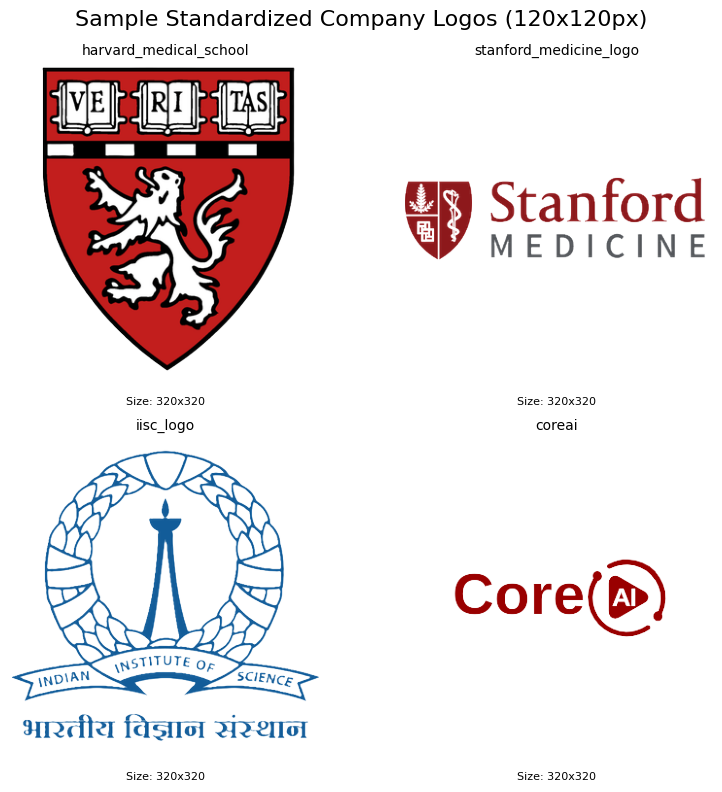

✅ All company logos have been successfully standardized!
📁 Find them in: img/company_standardized
📐 All images are now 120x120 pixels with consistent formatting
🖼️ Transparent backgrounds preserved
📱 Ready for both desktop and mobile display


In [20]:
# Display a sample of processed images to verify quality
import matplotlib.pyplot as plt

# Select a few images to display
sample_images = ['harvard_medical_school.png', 'stanford_medicine_logo.png', 'iisc_logo.png', 'coreai.png']

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
fig.suptitle('Sample Standardized Company Logos (120x120px)', fontsize=16)

for i, img_name in enumerate(sample_images):
    if i < 4:  # Display max 4 images
        row = i // 2
        col = i % 2
        
        img_path = os.path.join(OUTPUT_FOLDER, img_name)
        if os.path.exists(img_path):
            img = Image.open(img_path)
            axes[row, col].imshow(img)
            axes[row, col].set_title(img_name.replace('.png', ''), fontsize=10)
            axes[row, col].axis('off')
            
            # Show image dimensions
            axes[row, col].text(0.5, -0.1, f'Size: {img.size[0]}x{img.size[1]}', 
                              transform=axes[row, col].transAxes, 
                              ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print("✅ All company logos have been successfully standardized!")
print(f"📁 Find them in: {OUTPUT_FOLDER}")
print("📐 All images are now 120x120 pixels with consistent formatting")
print("🖼️ Transparent backgrounds preserved")
print("📱 Ready for both desktop and mobile display")